# Población hablante de lengua indígena

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline

### Datos del INEGI sobre lenguas indígenas en el país

In [2]:
banco_info_df = pd.read_excel("data/lengua_00.xlsx", engine="openpyxl", skiprows=4)

In [3]:
banco_info_df.head()

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,1930,1940,1950,1960,1970,1990,1995,2000,2005,2010,2015,2020,unidad_medida
0,0.0,Estados Unidos Mexicanos,0.0,Estados Unidos Mexicanos,1.005000e+09,Población de 5 años y más hablante de lengua i...,NaN,NaN,NaN,NaN,NaN,NaN,5483555,6044547,6011202.0,6.695228e+06,NaN,7.177185e+06,Personas
1,0.0,Estados Unidos Mexicanos,0.0,Estados Unidos Mexicanos,6.200240e+09,Tasa de monolingüismo de la población de 5 año...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.020760e+01,14.6948729582577,1.381374e+01,Porcentaje
2,0.0,Estados Unidos Mexicanos,0.0,Estados Unidos Mexicanos,6.200240e+09,Tasa de monolingüismo de la población de 5 año...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.514331e+00,3.95522388059702,4.234629e+00,Porcentaje
3,0.0,Estados Unidos Mexicanos,0.0,Estados Unidos Mexicanos,6.200240e+09,Población de 5 años y más hablante de Tzeltal ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.458560e+05,NaN,5.592620e+05,Personas
4,0.0,Estados Unidos Mexicanos,0.0,Estados Unidos Mexicanos,6.200240e+09,Tasa de monolingüismo de la población de 5 año...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.903502e+01,14.7977444189819,1.219246e+01,Porcentaje


In [4]:
indicator_id = 1005000039 # Población de 5 años y más hablante de lengua indígena
nacional = banco_info_df[
    (banco_info_df["id_indicador"] == indicator_id)
    & (banco_info_df["desc_municipio"] == "Estatal")
]

In [5]:
# Cargamos los campos importantes
important_years = ["1995", "2000", "2005", "2010", "2020"]
important_fields = ["cve_entidad", "desc_entidad", *important_years]
nacional_poblacion_indigena = nacional[important_fields].copy()

# Transformamos algunos campos a campos numéricos
nacional_poblacion_indigena["cve_entidad"] = nacional_poblacion_indigena["cve_entidad"].astype(int)
nacional_poblacion_indigena["1995"] = nacional_poblacion_indigena["1995"].astype(float)
nacional_poblacion_indigena["2000"] = nacional_poblacion_indigena["2000"].astype(float)

# Visualizamos información de los datos
print(nacional_poblacion_indigena.shape)
print(nacional_poblacion_indigena.isna().sum())
print(nacional_poblacion_indigena.dtypes)
nacional_poblacion_indigena.head()

(32, 7)
cve_entidad     0
desc_entidad    0
1995            0
2000            0
2005            0
2010            0
2020            0
dtype: int64
cve_entidad       int64
desc_entidad     object
1995            float64
2000            float64
2005            float64
2010            float64
2020            float64
dtype: object


,cve_entidad,desc_entidad,1995,2000,2005,2010,2020
47,1,Aguascalientes,729.0,1244.0,2713.0,2436.0,2508.0
611,2,Baja California,22912.0,37685.0,33604.0,41005.0,48638.0
940,3,Baja California Sur,3468.0,5353.0,7095.0,10661.0,13495.0
1222,4,Campeche,89180.0,93765.0,89084.0,91094.0,91020.0
1833,5,Coahuila de Zaragoza,2039.0,3032.0,5842.0,6105.0,5481.0


In [6]:
# Total de población de 5 años y más hablante de lengua indígena
poblacion_lengua_indigena = nacional_poblacion_indigena[important_years].sum()
poblacion_lengua_indigena

1995    5483555.0
2000    6044547.0
2005    6011202.0
2010    6695228.0
2020    7177185.0
dtype: float64

### Cargar datos total de población mexicana

In [7]:
# Total de la población mexicana
poblacion_mexicana = pd.read_csv("data/poblacion_mexicana.csv", encoding="utf-16le", usecols=important_years)
poblacion_mexicana = poblacion_mexicana.iloc[0].copy()
poblacion_mexicana

1995     91158290.0
2000     97483412.0
2005    103263388.0
2010    112336538.0
2020    126014024.0
Name: 0, dtype: float64

In [8]:
# Elegimos años extremos con datos disponible
# para la población de 5 años y más hablante 
# de lengua indígena
important_years = ["1995", "2020"]

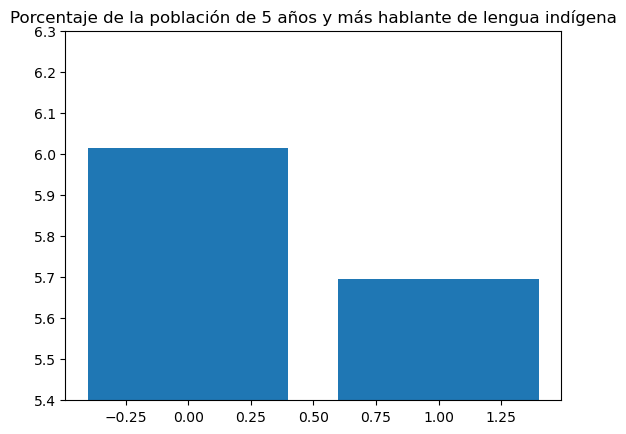

In [9]:
percentages = []

for idx in important_years:
    percentage = poblacion_lengua_indigena[idx] / poblacion_mexicana[idx] * 100
    percentages.append(percentage)

plt.bar(x=range(len(percentages)), height=percentages)
plt.ylim(5.4,6.3)
plt.title("Porcentaje de la población de 5 años y más hablante de lengua indígena")
plt.show()

In [10]:
from shapely.geometry import MultiPolygon, Polygon

def filter_by_area(geom: Polygon | MultiPolygon, area_min: int):
    """
    Devuelve una geometría sin los polígonos menores a area_min.
    Acepta Polygon o MultiPolygon.
    """
    # Si es un Polygon único
    if isinstance(geom, Polygon):
        return geom if geom.area >= area_min else None

    # Si es un MultiPolygon
    elif isinstance(geom, MultiPolygon):
        # Filtrar los polígonos grandes
        geoms_filtrados = [p for p in geom.geoms if p.area >= area_min]
        if len(geoms_filtrados) == 0:
            return None
        elif len(geoms_filtrados) == 1:
            return geoms_filtrados[0]
        else:
            return MultiPolygon(geoms_filtrados)

    # Si no es ninguno de los anteriores
    else:
        return None

### Cargar datos geográficos de México

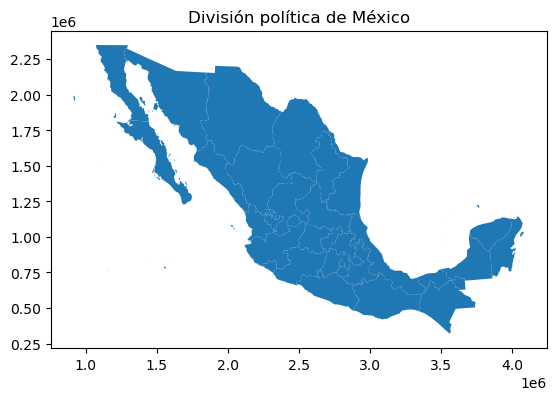

In [11]:
# --- Cargar shapefile ---
mexico = gpd.read_file("data/dest24gw_c/dest24cw.shp", encoding="utf8")
mexico.plot()
plt.title("División política de México")
plt.show()

In [12]:
area_lim = 0.5e10  # límite de área

# --- Graficar ---
for idx, row in mexico.iterrows():
    geometry = row.geometry
    if geometry.geom_type == "MultiPolygon":
        serie = mexico.loc[idx].copy()
        geometry = serie["geometry"]
        serie["geometry"] = filter_by_area(geometry, area_lim)
        mexico.loc[idx] = serie

mexico_latlng = mexico.to_crs("epsg:4326")
mexico_latlng["CVE_ENT"] = mexico_latlng["CVE_ENT"].astype(int)

In [13]:
mexico_latlng.head()

,CVEGEO,CVE_ENT,NOMGEO,COV_,COV_ID,geometry
0,01,1,Aguascalientes,0,1,"POLYGON ((-102.29739 22.45527, -102.29554 22.4..."
1,02,2,Baja California,1,2,"POLYGON ((-117.10047 32.53656, -117.09922 32.5..."
2,03,3,Baja California Sur,2,3,"POLYGON ((-113.55 28, -113.54167 28, -113.5333..."
3,04,4,Campeche,3,4,"POLYGON ((-90.37936 20.84833, -90.38182 20.749..."
4,05,5,Coahuila de Zaragoza,4,5,"POLYGON ((-102.31549 29.88, -102.31509 29.8799..."


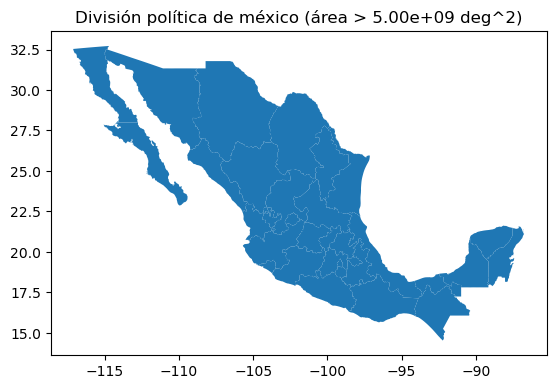

In [14]:
mexico_latlng.plot()
plt.title(f"División política de méxico (área > {area_lim:.2e} deg^2)")
plt.show()

### Mezclar información de lenguas indígenas y división política de estados

In [15]:
lenguas_mexico = mexico_latlng.merge(
    right=nacional_poblacion_indigena[["cve_entidad", *important_years]], 
    how="inner", left_on="CVE_ENT", right_on="cve_entidad")

lenguas_mexico.describe()

,CVE_ENT,COV_,COV_ID,cve_entidad,1995,2020
count,32.000000,32.000000,32.000000,32.000000,3.200000e+01,3.200000e+01
mean,16.500000,15.500000,16.500000,16.500000,1.713611e+05,2.242870e+05
std,9.380832,9.380832,9.380832,9.380832,2.574472e+05,3.374538e+05
min,1.000000,0.000000,1.000000,1.000000,7.290000e+02,2.508000e+03
25%,8.750000,7.750000,8.750000,8.750000,1.772600e+04,3.005950e+04
50%,16.500000,15.500000,16.500000,16.500000,4.035750e+04,7.180950e+04
75%,24.250000,23.250000,24.250000,24.250000,2.379840e+05,2.590945e+05
max,32.000000,31.000000,32.000000,32.000000,1.027847e+06,1.387295e+06


In [16]:
lenguas_mexico[lenguas_mexico["NOMGEO"] == "Yucatán"]

,CVEGEO,CVE_ENT,NOMGEO,COV_,COV_ID,geometry,cve_entidad,1995,2020
30,31,31,Yucatán,30,31,"POLYGON ((-88.00659 21.61046, -88.00652 21.609...",31,545902.0,520580.0


#### Tratemos de escalar los valores en millones

In [17]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

# Crear la cuadrícula de subplots
important_years = ["1995", "2020"]
n = len(important_years)
ncols = 2
nrows = (n + ncols - 1) // ncols

# Configurar el rango de valores de la escala
min = lenguas_mexico[important_years].min().min()
max = lenguas_mexico[important_years].max().max()

# Calcular un desplazamiento 
delta = max - min 
center = min + delta / 2
shift = 0.7 # Proportion 0 - 1
distance_shift = (1 - shift) * center
vmin = min + distance_shift
vmax = max - distance_shift


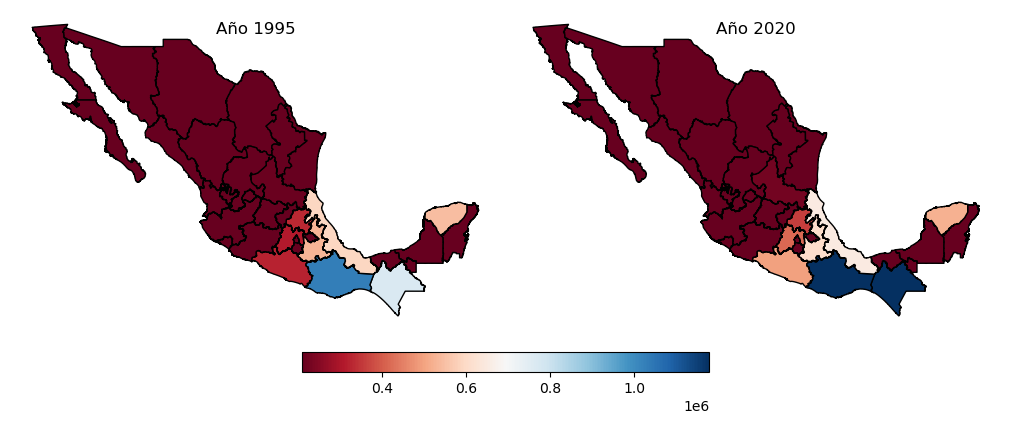

In [18]:
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5 * ncols, 5 * nrows),
    constrained_layout=True
)

axes = axes.flatten()

for i, year in enumerate(important_years):
    ax = axes[i]
    lenguas_mexico.plot(
        column=year,
        cmap="RdBu",
        edgecolor="k",
        vmin=vmin, vmax=vmax,
        legend=False,
        ax=ax
    )
    ax.set_title(f"Año {year}", fontsize=12, y=0.9)
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap="RdBu", norm=Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)

def millones(x, pos):
    return f"{x/1_000_000:.0f}"

# cbar.ax.xaxis.set_major_formatter(FuncFormatter(millones))
# cbar.set_ticks(ticks)
# cbar.set_label("Población (millones)", fontsize=11)

plt.show()


#### Ahora escalemos con porcentaje de población

In [19]:
lenguas_mexico_percentage = lenguas_mexico.copy()

for year in important_years:
    total = lenguas_mexico[year].sum()
    lenguas_mexico_percentage[year] = lenguas_mexico_percentage[year] / poblacion_mexicana[year] * 100

lenguas_mexico_percentage.describe()

,CVE_ENT,COV_,COV_ID,cve_entidad,1995,2020
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,16.500000,15.500000,16.500000,16.500000,0.187982,0.177986
std,9.380832,9.380832,9.380832,9.380832,0.282418,0.267791
min,1.000000,0.000000,1.000000,1.000000,0.000800,0.001990
25%,8.750000,7.750000,8.750000,8.750000,0.019445,0.023854
50%,16.500000,15.500000,16.500000,16.500000,0.044272,0.056985
75%,24.250000,23.250000,24.250000,24.250000,0.261067,0.205608
max,32.000000,31.000000,32.000000,32.000000,1.127541,1.100905


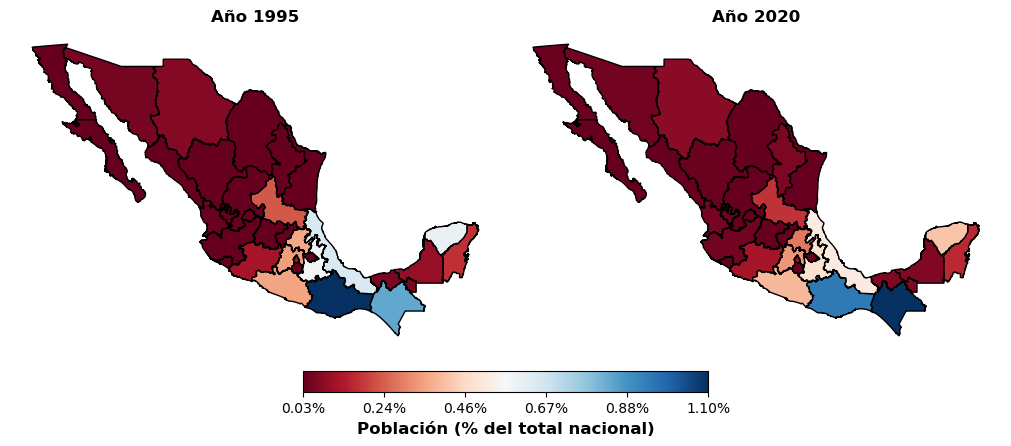

vmin = 0.0007997078488418332, vmax = 1.1275408961708255
vmin_a = 0.030799707848841833, vmax_a = 1.0975408961708255


In [20]:
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt
import numpy as np

# Crear la cuadrícula de subplots
important_years = ["1995", "2020"]
n = len(important_years)
ncols = 2
nrows = (n + ncols - 1) // ncols

vmin = lenguas_mexico_percentage[important_years].min().min()
vmax = lenguas_mexico_percentage[important_years].max().max()

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5 * ncols, 5 * nrows),
    constrained_layout=True
)

axes = axes.flatten()

shift = 0.03
vmin_adj = vmin + shift
vmax_adj = vmax - shift

# --- Dibujar los mapas sin leyenda individual ---
for i, year in enumerate(important_years):
    ax = axes[i]
    lenguas_mexico_percentage.plot(
        column=year,
        cmap="RdBu",
        edgecolor="k",
        vmin=vmin_adj, vmax=vmax_adj,
        legend=False,  # <- desactivamos leyenda individual
        ax=ax
    )
    ax.set_title(f"Año {year}", fontsize=12, fontweight=700)
    ax.axis("off")

# --- Crear UNA sola barra de color global ---
# Agregamos una figura vacía para obtener la barra común
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=plt.Normalize(vmin=vmin_adj, vmax=vmax_adj))
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)

# Formato con símbolo de porcentaje (%)
ticks = np.linspace(vmin_adj, vmax_adj, 6)
cbar.set_ticks(ticks)
cbar.ax.xaxis.set_major_formatter(PercentFormatter(xmax=1 if vmax <= 1 else 100))
cbar.set_label("Población (% del total nacional)", fontsize=12, fontweight="bold")

plt.show()
print(f"vmin = {vmin}, vmax = {vmax}")
print(f"vmin_a = {vmin_adj}, vmax_a = {vmax_adj}")

De este modo, vemos que considerando porcentaje de la población total de méxico, se obtiene un mejor ajuste de colores

In [21]:
yucatan = mexico_latlng[mexico_latlng["NOMGEO"] == "Yucatán"]

yucatan

,CVEGEO,CVE_ENT,NOMGEO,COV_,COV_ID,geometry
30,31,31,Yucatán,30,31,"POLYGON ((-88.00659 21.61046, -88.00652 21.609..."


In [31]:
polygon = yucatan["geometry"][30]

In [107]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
# from shapely.geometry import Polygon
from mpl_toolkits.mplot3d import Axes3D

# Ejemplo: un polígono de 4 puntos
poly = polygon

# Obtener coordenadas x, y
x, z = poly.exterior.xy

fig = plt.figure(figsize=(7,10))
ax = fig.add_subplot(111, projection='3d')

# Crear la colección 3D
for i in range(0, 5):
    y = [i*2] * len(x)
    verts = [list(zip(x, y, z))]
    collection = Poly3DCollection(verts, alpha=0.6, facecolor='lightblue', edgecolor='black')
    ax.add_collection3d(collection)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
# ax.set_yticks(list(range(1,5*2)))

# Configurar límites y vista
# ax.set_xlim(np.min(y), np.max(y))
# ax.set_ylim(np.min(x), np.max(x))
# ax.set_zlim(0, 1)
ax.set_axis_off()
x_scale=1
y_scale=2
z_scale=1
scale=np.diag([x_scale, y_scale, z_scale, 1.0])
# scale[3,3]=1.0
ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), scale)
ax.view_init(elev=20, azim=-70)

plt.show()


AttributeError: 'Axes3D' object has no attribute 'dist'

<Figure size 700x1000 with 1 Axes>